In [ ]:
import sys
sys.path.insert(0, "/Users/adrianjuarez/Documents/Covert_lab/Repos/mother_machine_cell_tracker")
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from mmtrack import pre_process_mm
from mmtrack import plot_cells
import warnings
import networkx as nx
import tifffile
from skimage.filters import threshold_otsu
import skimage.segmentation as segmentation
from skimage import segmentation, morphology, measure, filters
import scipy.ndimage as ndi
from skimage.filters import threshold_local
import json

Helper functions:

In [34]:
def get_tiff_frame_count(file_path):
	"""Reads a TIFF file and returns the index of the last time frame (T - 1)."""
	try:
		# 1. Read the image data into a NumPy array
		img_stack = tf.imread(file_path)

		# 2. Get the shape of the array
		shape = img_stack.shape

		# 3. Assume the time axis (T) is the first dimension
		if len(shape) >= 3:
			# The last index is T - 1, which is shape[0] - 1
			last_frame_index = shape[0] - 1
			return last_frame_index
		else:
			# Handle case where the file might be a single 2D image (T=1, last index 0)
			return 0

	except FileNotFoundError:
		print(f"Error: TIFF file not found at {file_path}")
		return 0
	except Exception as e:
		print(f"Error reading TIFF file {file_path}: {e}")
		return 0
	
def overlap(bbox1, bbox2):
    """Checks if two bounding boxes overlap."""
    x1 = max(bbox1[0], bbox2[0])
    y1 = max(bbox1[1], bbox2[1])
    x2 = min(bbox1[2], bbox2[2])
    y2 = min(bbox1[3], bbox2[3])
    return x1 < x2 and y1 < y2

Fill in file you want to troubleshoot and the experiment dictionary in json text format

In [ ]:
# this code snippet will be used to create the full exp_dict that I can use to break down later

In [2]:
file_name = "/Volumes/mcovert/Instruments/Covert-lab-scope1/in_progress"
folder = 'DUMM_baeS_gfcE_112025'
base_dir = file_name


In [ ]:
# Using this to save final terminal calls
EXP_DICT='{"DUMM_baeS_gfcE_112025": {"005": ["872","1782"]}}'
EXP_DICT='{"DUMM_baeS_gfcE_112025": {"005": ["872"]}}'
STRAIN_DICT='{"baeS": {"DUMM_baeS_gfcE_112025": ["005"]}, "gfcE": {"DUMM_baeS_gfcE_112025": ["011", "012", "016"]}}'

In [ ]:
# Use for testing individual trench
BASE_DIR = "/Volumes/mcovert/Instruments/Covert-lab-scope1/in_progress"
EXP_DICT ='{"DUMM_baeS_gfcE_112025": {"022": ["377"]}}'
STRAIN_DICT='{"DUMM_baeS_gfcE_112025": {"baeS": ["022"]}}'

In [9]:
exp_dict_full_005 ='{"DUMM_baeS_gfcE_112025": {"005": ["872","1782"]}}'
exp_dict_full_011 ='{"DUMM_baeS_gfcE_112025": {"011": ["171","247","635","1619"]}}'
exp_dict_full_012 ='{"DUMM_baeS_gfcE_112025": {"012": ["244","1156","1460"]}}'
exp_dict_full_016 ='{"DUMM_baeS_gfcE_112025": {"016": ["247","1537"]}}'
seg_FOV_dict = json.loads(exp_dict_full_016)

In [4]:
base_dir= base_dir
exp_dict_json= exp_dict_full_005
start_frame=0
end_frame = 90  # Passes None if not provided
phase_c_str='0'
otsu_thresh=1.5
first_open=4
dist_thresh=3.0
second_open_size=3
min_area=100
max_area=1000
small_merge_thresh=100

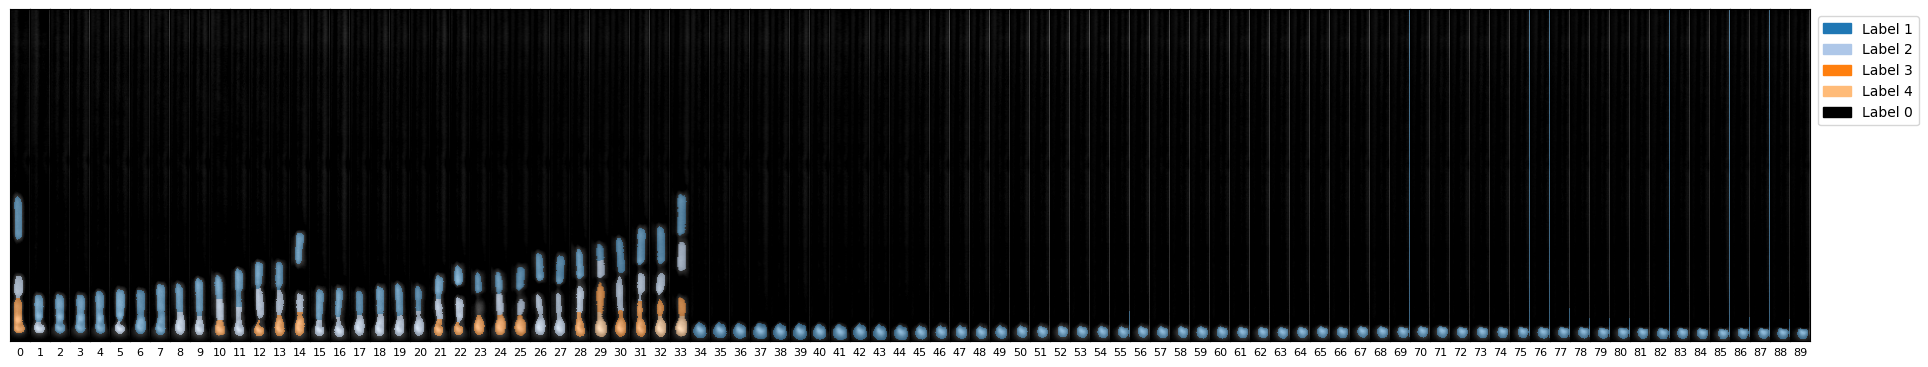

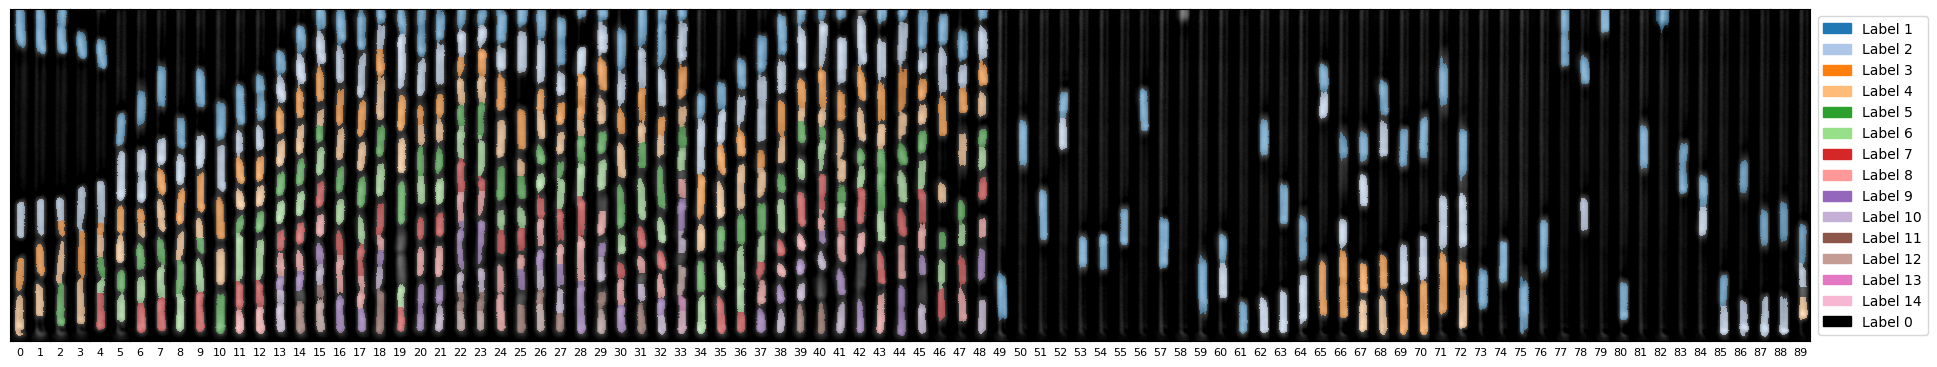

In [10]:
#previous troubhleshooting setup
phase_channel = '0'
fluor_channel = '1'
for folder, fov_dict in seg_FOV_dict.items():
    for fov_id in fov_dict.keys():
        ana_peak_ids = fov_dict[fov_id]
        for peak_id in ana_peak_ids:
            current_end_frame = end_frame
            path_to_phase_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            if current_end_frame is None:
                current_end_frame = get_tiff_frame_count(path_to_phase_stack)
            path_to_fluor_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{fluor_channel}.tif'
            output_path = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/outputs'
            labeled_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/mm3_segmented_subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            mm3seg.segment_chnl_stack(
                   path_to_phase_stack,
                   output_path,
                   OTSU_threshold=1.5,
                   first_opening=4,
                   distance_threshold=2,
                   second_opening_size=2,
                   min_cell_area=75,
				   max_cell_area=1000,
                   small_merge_area_threshold=100)
            plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=0, end=90, alpha=0.5)
            # plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=34, end=35, alpha=0.5)

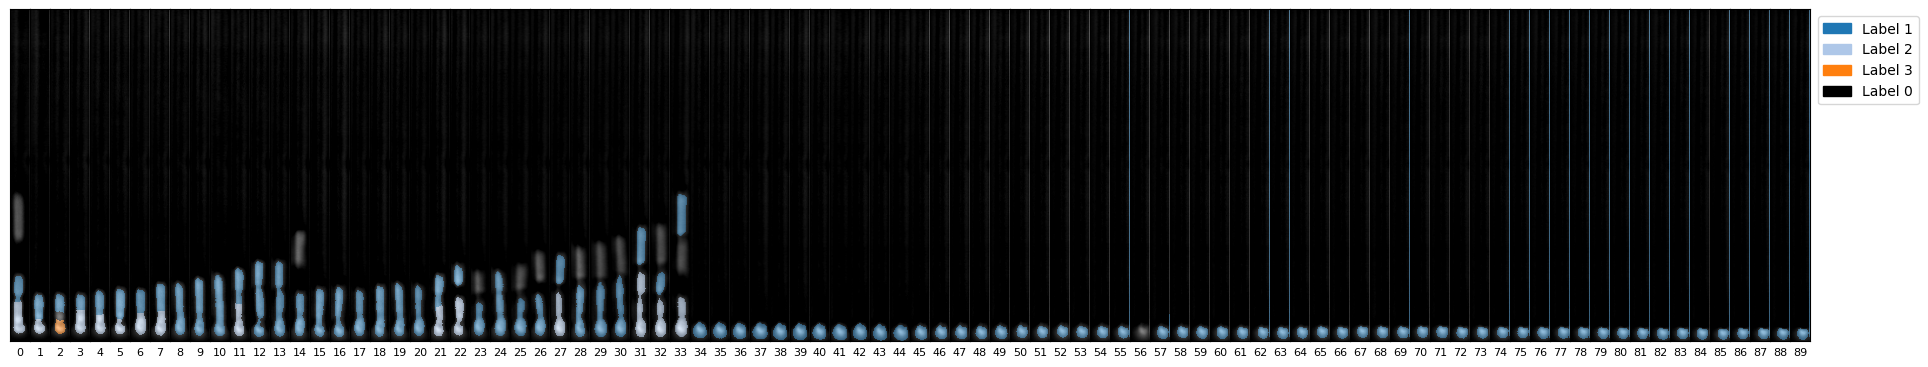

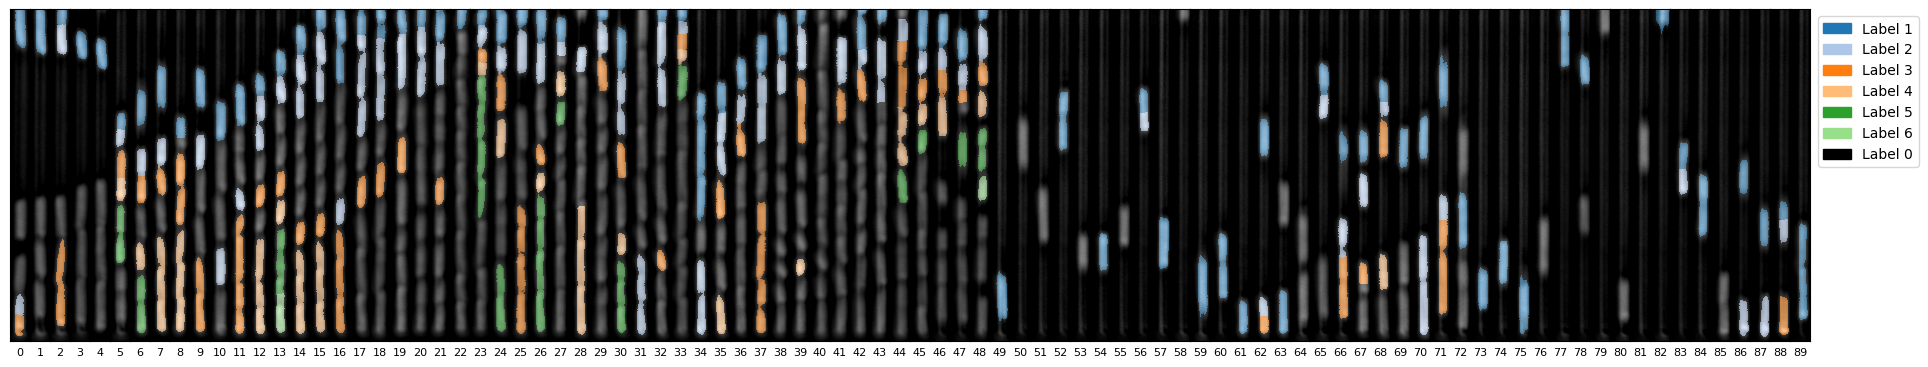

In [45]:
#previous troubhleshooting setup
phase_channel = '0'
fluor_channel = '1'
for folder, fov_dict in seg_FOV_dict.items():
    for fov_id in fov_dict.keys():
        ana_peak_ids = fov_dict[fov_id]
        for peak_id in ana_peak_ids:
            current_end_frame = end_frame
            path_to_phase_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            if current_end_frame is None:
                current_end_frame = get_tiff_frame_count(path_to_phase_stack)
            path_to_fluor_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{fluor_channel}.tif'
            output_path = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/outputs'
            labeled_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/mm3_segmented_subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            mm3seg.segment_chnl_stack(
                   path_to_phase_stack,
                   output_path,
                   OTSU_threshold=1.4,
                   first_opening=2,
                   distance_threshold=3,
                   second_opening_size=2,
                   min_cell_area=100,
				   max_cell_area=1000,
                   small_merge_area_threshold=50)
            plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=0, end=90, alpha=0.5)
            # plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=34, end=35, alpha=0.5)

# Troubleshooting begins here:
First pick a timeframe

In [ ]:
print(path_to_phase_stack)
print("/Volumes/mcovert/Instruments/Covert-lab-scope1/in_progress’/DUMM_gitg068_baeS_100225/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_022_region_1281_c_0.tif")

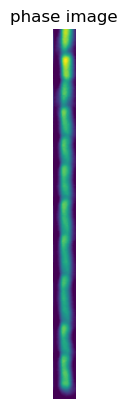

In [13]:
fov ='16'
peak_id ='1537'
frame=22
path_to_phase_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
image = tifffile.imread(path_to_phase_stack)[frame]
plt.figure()
plt.imshow(image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

# Otsu threshold
Test different otsu_thresh values. The mask will be dependent on the otsu threshold, individual cell labeling will depend on everything else so it is okay if cells are somewhat joined together

Main goal is to make sure we see the correct number of cells

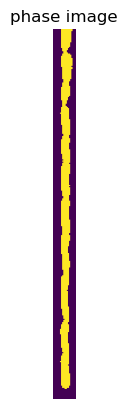

In [15]:
otsu_thresh = 1.4

# normalization if using 
# scale = np.median(image) / np.mean(image)
# image = image.astype(np.float32)
# image = (image - np.percentile(image, 1)) / (
#     np.percentile(image, 99) - np.percentile(image, 1)
# )
# image = np.clip(image, 0, 1)

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        thresh = filters.threshold_otsu(image)
    thresholded = image > otsu_thresh * thresh
    
except Exception as e:
        print(f"Error in initial processing: {e}")

plt.figure()
plt.imshow(thresholded)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()


# First opening
Here wee mess with the first opening. Ultimately want to maintain centroids here so don't worry about how small cells are. 

You may need to change the morphological opening shape for either diagnol or spherical 

In [ ]:
first_opening_top = 2
first_opening_bottom = 4
height = image.shape[0]
mid_height = height // 2
top_half = thresholded[:mid_height]
bottom_half = thresholded[mid_height:]

diagonal_footprint_top = np.zeros((first_opening_top, first_opening_top))
morph_top = morphology.binary_opening(thresholded, morphology.disk(first_opening_top))

diagonal_footprint_bottom = np.zeros((first_opening_bottom, first_opening_bottom))
np.fill_diagonal(diagonal_footprint_bottom, 1)
morph_bottom = morphology.binary_opening(bottom_half, diagonal_footprint_bottom)

# Combine the processed halves
morph = np.vstack((morph_top, morph_bottom))

plt.figure()
plt.imshow(merged_morph)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

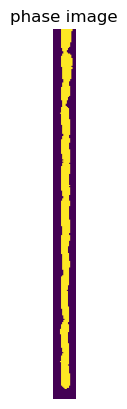

In [18]:
# change but is int not double 
first_opening = 2
#if spherical opening use the following code 
# morph = morphology.binary_opening(thresholded, morphology.disk(first_opening))


#if diagnol opening use the following code
diagonal_footprint = np.zeros((first_opening, first_opening))
np.fill_diagonal(diagonal_footprint, 1)
morph = morphology.binary_opening(thresholded, diagonal_footprint)

plt.figure()
plt.imshow(morph)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

# Distance threshold 
Again goal is to retain the number of objects here and make sure cells are separate 

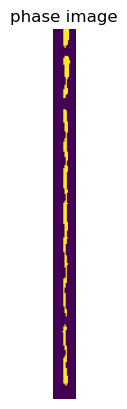

In [24]:
distance_threshold = 3
distance = ndi.distance_transform_edt(morph)
distance_thresh = distance >= distance_threshold
plt.figure()
plt.imshow(distance_thresh)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()



# Second opening 
Further segment cells, can opt to not use it by setting the value to 0

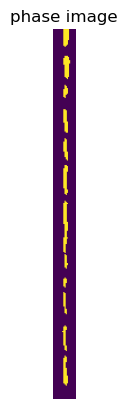

In [26]:
second_opening_size = 2
# distance_opened = morphology.binary_opening(distance_thresh, morphology.disk(second_opening_size))

diagonal_footprint = np.zeros((second_opening_size, second_opening_size))
np.fill_diagonal(diagonal_footprint, 1)
distance_opened = morphology.binary_opening(distance_thresh, diagonal_footprint)

plt.figure()
plt.imshow(distance_opened)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

# labeling and markers 
Apply labels to cells that have been segmented. Labeled will be used for watershed I believe markers will be used only to create a mask 

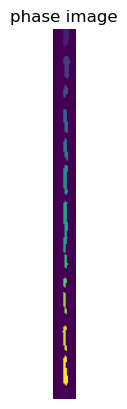

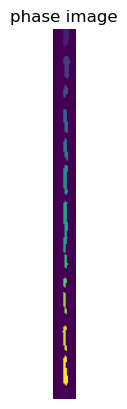

In [29]:
labeled, num_labels = morphology.label(distance_opened, connectivity=1, return_num=True)
markers = morphology.label(labeled, connectivity=1)
markers = markers.astype(np.int32)

plt.figure()
plt.imshow(labeled)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

plt.figure()
plt.imshow(markers)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()


# Watershed begins here 

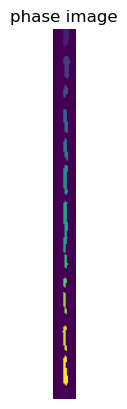

In [30]:
thresholded_watershed = distance_opened
image_float = image.astype(np.float64)
markers[thresholded_watershed == 0] = -1
with warnings.catch_warnings():
     warnings.simplefilter("ignore")
     labeled_image = segmentation.random_walker(-1 * image_float, markers)
labeled_image[labeled_image == -1] = 0

plt.figure()
plt.imshow(labeled_image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()


/opt/miniconda3/envs/mmct/lib/python3.11/site-packages/skimage/segmentation/random_walker_segmentation.py:545: UserWarning: Random walker only segments unlabeled areas, where labels == 0. No zero valued areas in labels were found. Returning provided labels.
  (labels, nlabels, mask, inds_isolated_seeds, isolated_values) = _preprocess(labels)


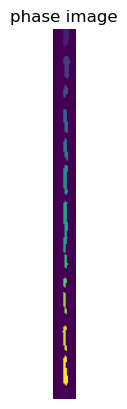

In [31]:
labeled_image = segmentation.random_walker(-1 * image_float, markers)
labeled_image[labeled_image == -1] = 0
plt.figure()
plt.imshow(labeled_image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

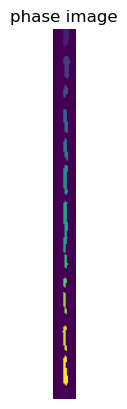

In [40]:
small_merge_area_threshold=10
regions = measure.regionprops(labeled_image)
if regions:
        bboxes = np.array([region.bbox for region in regions])
        areas = np.array([region.area for region in regions])
        graph = nx.Graph()

        for i, bbox1 in enumerate(bboxes):
            for j, bbox2 in enumerate(bboxes):
                if i != j and overlap(bbox1, bbox2) and areas[i] < small_merge_area_threshold and areas[j] < small_merge_area_threshold:
                    graph.add_edge(regions[i].label, regions[j].label)

        for component in nx.connected_components(graph):
            if len(component) > 1:
                merged_mask = np.isin(labeled_image, list(component))
                new_label = np.max(labeled_image) + 1
                labeled_image[merged_mask] = new_label
                for label in component:
                    labeled_image[labeled_image == label] = 0

        labeled_image, _ = morphology.label(labeled_image, connectivity=1, return_num=True)

plt.figure()
plt.imshow(labeled_image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()


### Shape Filtering (axis Ratio)

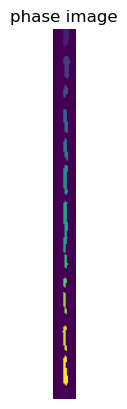

In [36]:
min_axis_ratio=0.04 # 0.04 is the default value
filtered_labeled_image = np.zeros_like(labeled_image)
regions = measure.regionprops(labeled_image)

for region in regions:
    if region.axis_major_length > 0:
        axis_ratio = region.axis_minor_length / region.axis_major_length
        if (axis_ratio > min_axis_ratio) | (region.axis_minor_length > 3.5):
            filtered_labeled_image[region.coords[:, 0], region.coords[:, 1]] = region.label

    labeled_image = filtered_labeled_image

plt.figure()
plt.imshow(labeled_image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

### size filtering

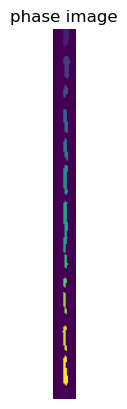

In [37]:
min_cell_area =10
max_cell_area =350
if min_cell_area is not None or max_cell_area is not None:
        filtered_labeled_image = np.zeros_like(labeled_image)
        regions = measure.regionprops(labeled_image)
        for region in regions:
            area = region.area
            if (min_cell_area is None or area >= min_cell_area) and (max_cell_area is None or area <= max_cell_area):
                filtered_labeled_image[region.coords[:, 0], region.coords[:, 1]] = region.label
        new_labeled_image = filtered_labeled_image

plt.figure()
plt.imshow(new_labeled_image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()